Square wave + Harmonics reconstruction

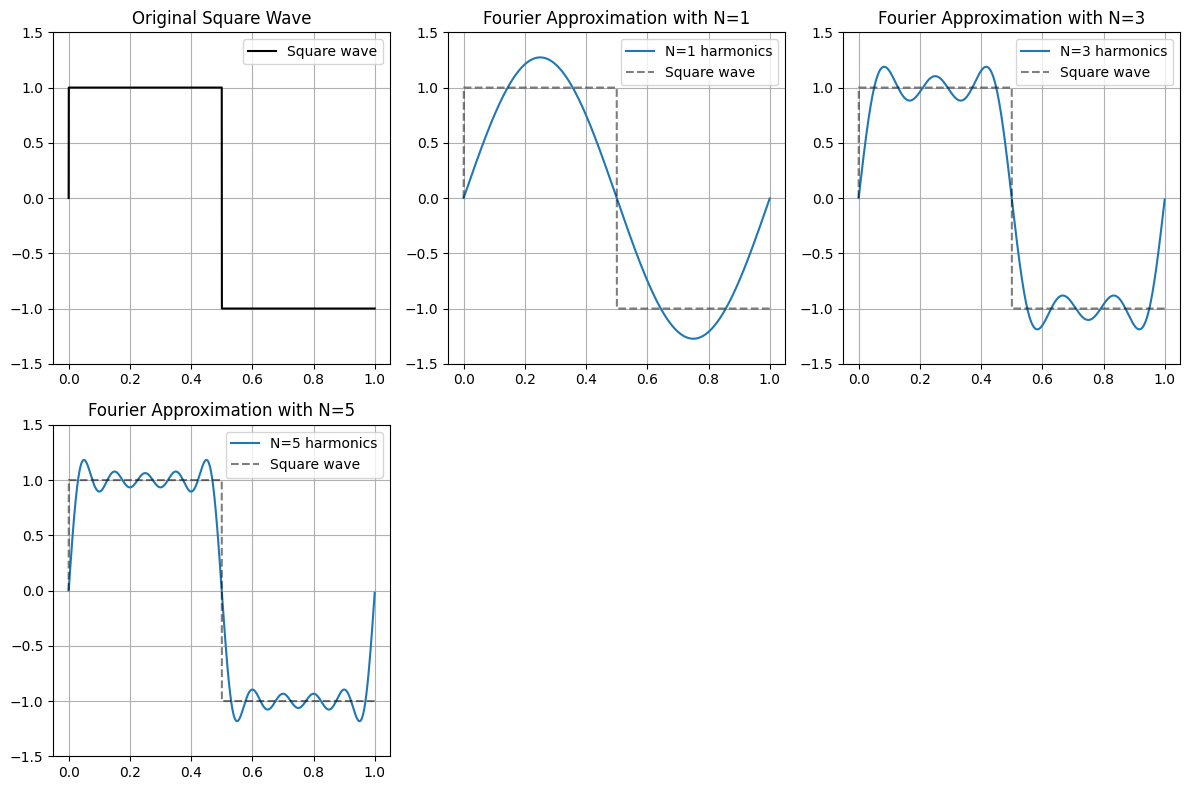

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Set parameters for the signal
N = 2048  # Number of sample points
T = 1.0   # Duration of the signal in seconds
f0 = 1    # Fundamental frequency of the square wave in Hz

# List of harmonic numbers used to construct the square wave
harmonics = [1, 3, 5]

# Define the square wave function
def square_wave(t):
    return np.sign(np.sin(2.0 * np.pi * f0 * t))

# Fourier series approximation of the square wave
def square_wave_fourier(t, f0, N):
    result = np.zeros_like(t)
    for k in range(N):
        # The Fourier series of a square wave contains only odd harmonics.
        n = 2 * k + 1
        # Add harmonics to reconstruct the square wave.
        result += np.sin(2 * np.pi * n * f0 * t) / n
    return (4 / np.pi) * result

# Create the time vector
# np.linspace generates evenly spaced numbers over a specified interval.
# We use endpoint=False because the interval is periodic.
t = np.linspace(0.0, T, N, endpoint=False)

# Generate the original square wave
square = square_wave(t)

plt.figure(figsize=(12, 8))

# Plot the original square wave
plt.subplot(2, 3, 1)
plt.plot(t, square, 'k', label="Square wave")
plt.title("Original Square Wave")
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.legend()

# Plot Fourier reconstructions under different number of harmonics
for i, Nh in enumerate(harmonics, start=2):
    plt.subplot(2, 3, i)
    y = square_wave_fourier(t, f0, Nh)
    plt.plot(t, y, label=f"N={Nh} harmonics")
    plt.plot(t, square, 'k--', alpha=0.5, label="Square wave")
    plt.title(f"Fourier Approximation with N={Nh}")
    plt.ylim(-1.5, 1.5)
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

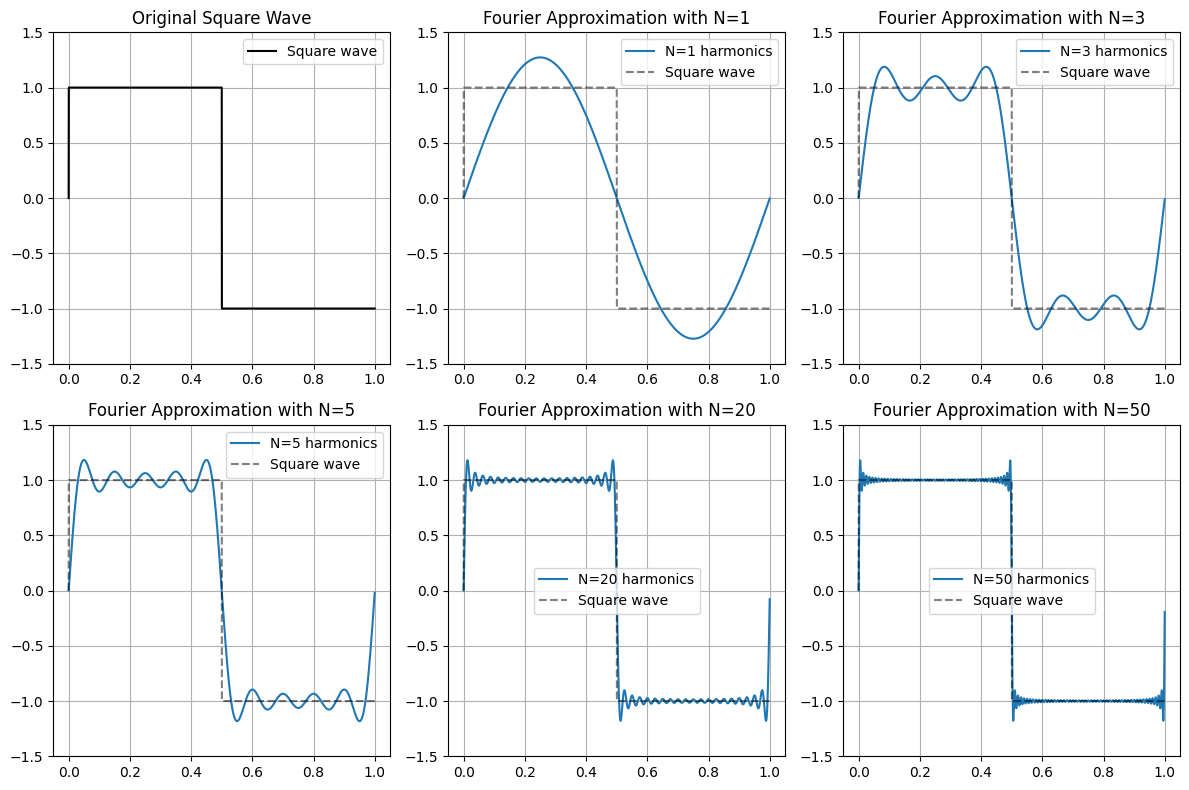

In [2]:
# Set parameters for the signal
N = 2048  # Number of sample points
T = 1.0   # Duration of the signal in seconds
f0 = 1    # Fundamental frequency of the square wave in Hz

# List of harmonic numbers used to construct the square wave
harmonics = [1,3,5,20,50]

# Define the square wave function
def square_wave(t):
    return np.sign(np.sin(2.0 * np.pi * f0 * t))

# Fourier series approximation of the square wave
def square_wave_fourier(t, f0, N):
    result = np.zeros_like(t)
    for k in range(N):
        # The Fourier series of a square wave contains only odd harmonics.
        n = 2 * k + 1
        # Add harmonics to reconstruct the square wave.
        result += np.sin(2 * np.pi * n * f0 * t) / n
    return (4 / np.pi) * result

# Create the time vector
# np.linspace generates evenly spaced numbers over a specified interval.
# We use endpoint=False because the interval is periodic.
t = np.linspace(0.0, T, N, endpoint=False)

# Generate the original square wave
square = square_wave(t)

plt.figure(figsize=(12, 8))

# Plot the original square wave
plt.subplot(2, 3, 1)
plt.plot(t, square, 'k', label="Square wave")
plt.title("Original Square Wave")
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.legend()

# Plot Fourier reconstructions under different number of harmonics
for i, Nh in enumerate(harmonics, start=2):
    plt.subplot(2, 3, i)
    y = square_wave_fourier(t, f0, Nh)
    plt.plot(t, y, label=f"N={Nh} harmonics")
    plt.plot(t, square, 'k--', alpha=0.5, label="Square wave")
    plt.title(f"Fourier Approximation with N={Nh}")
    plt.ylim(-1.5, 1.5)
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

Harmonics are just simple sine waves at multiples of a base frequency (1x,3x,5x,...) that get added together to build a more complex wave, like a square wave. Each one you add sharpens the corners and flattens the top/bottom a bit more: more harmonics.

Apply the DFT and time the execution

--- DFT/FFT Performance Comparison ---
Naive DFT Execution Time: 5.112412 seconds
NumPy FFT Execution Time: 0.007040 seconds
FFT is approximately 726.19 times faster.

Our DFT implementation is close to NumPy's FFT: True


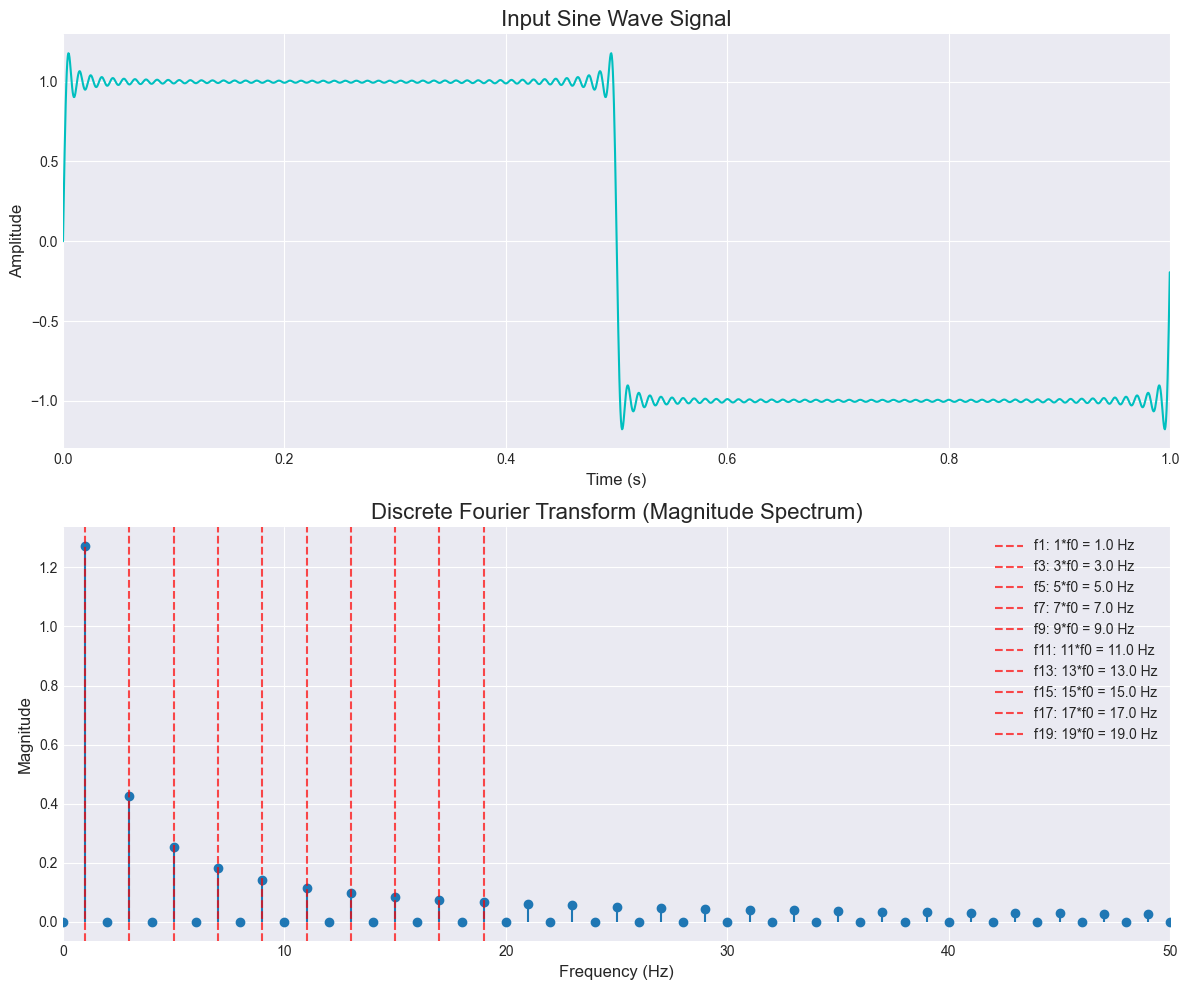

In [3]:

def naive_dft(x):
    """
    Compute the Discrete Fourier Transform (DFT) of a 1D signal.
    This is a "naive" implementation that directly follows the DFT formula,
    which has a time complexity of O(N^2).
    Args:
        x (np.ndarray): The input signal, a 1D NumPy array.
    Returns:
        np.ndarray: The complex-valued DFT of the input signal.
    """
    N = len(x)
    # Create an empty array of complex numbers to store the DFT results
    X = np.zeros(N, dtype=np.complex128)
    # Iterate through each frequency bin (k)
    for k in range(N):
        # For each frequency bin, sum the contributions from all input samples (n)
        for n in range(N):
            # The core DFT formula: x[n] * e^(-2j * pi * k * n / N)
            angle = -2j * np.pi * k * n / N
            X[k] += x[n] * np.exp(angle)
    return X

# Construct a square wave using 50 harmonics
signal = square_wave_fourier(t, f0, 50)

# Time the naive DFT implementation
start_time_naive = time.time()
dft_result = naive_dft(signal)
end_time_naive = time.time()
naive_duration = end_time_naive - start_time_naive

# Time NumPy's FFT implementation
start_time_fft = time.time()
fft_result = np.fft.fft(signal) # divide and conquer method (Quick method for same results)
end_time_fft = time.time()
fft_duration = end_time_fft - start_time_fft

# 3. Print Timings and Verification
print("--- DFT/FFT Performance Comparison ---")
print(f"Naive DFT Execution Time: {naive_duration:.6f} seconds")
print(f"NumPy FFT Execution Time: {fft_duration:.6f} seconds")

if fft_duration > 0:
    print(f"FFT is approximately {naive_duration / fft_duration:.2f} times faster.")
else:
    print("FFT was too fast to measure a significant duration difference.")

print(f"\nOur DFT implementation is close to NumPy's FFT: {np.allclose(dft_result, fft_result)}")

# 4. Prepare for Plotting
xf = np.fft.fftfreq(N, d=T/N)[:N//2]
magnitude = 2.0/N * np.abs(dft_result[0:N//2])

# 5. Visualize the Results
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.plot(t, signal, color='c')
ax1.set_title('Input Sine Wave Signal', fontsize=16)
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Amplitude', fontsize=12)
ax1.set_xlim(0, 1.0)
ax1.grid(True)

ax2.stem(xf, magnitude, basefmt=" ")
ax2.set_title('Discrete Fourier Transform (Magnitude Spectrum)', fontsize=16)
ax2.set_xlabel('Frequency (Hz)', fontsize=12)
ax2.set_ylabel('Magnitude', fontsize=12)
ax2.set_xlim(0, 50)
ax2.grid(True)

for i in range(20):
    if i < len(xf) and i % 2 == 1:
        ax2.axvline(
            xf[i], color='r', linestyle='--', alpha=0.7,
            label=f'f{i}: {i}*f0 = {xf[i]:.1f} Hz'
        )

ax2.legend()
plt.tight_layout()
plt.show()

Only odd harmonics have any magnitude (1, 3, 5, 7, 9... — the red dashed lines mark exactly these), and even harmonics (2, 4, 6, 8...) sit essentially at zero, barely visible dots along the baseline. That confirms the "square waves are built from only odd harmonics"

mps


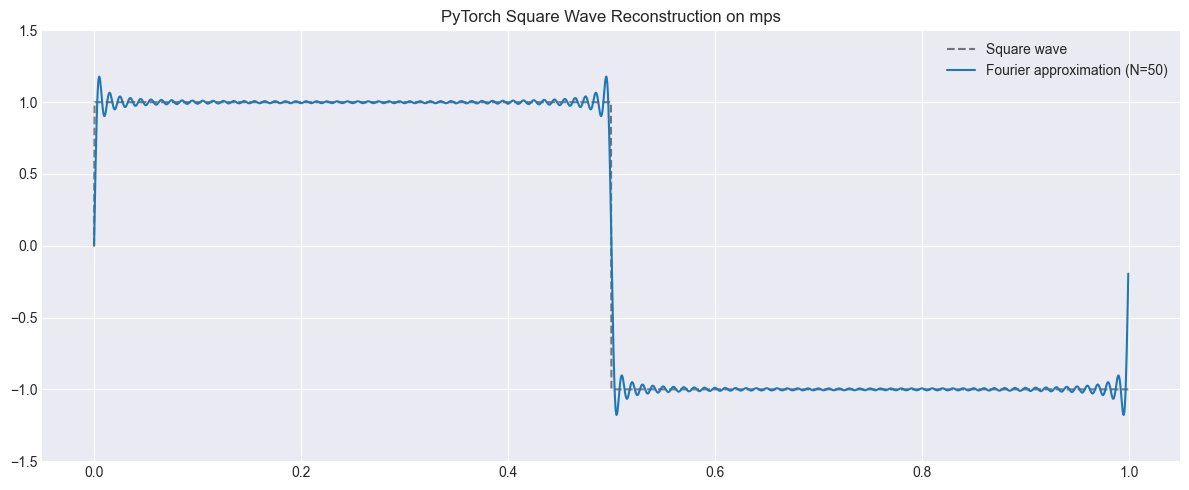

In [4]:
import torch

# Device configuration (mps if available, else cuda, else cpu)
device = torch.device(
    'mps' if torch.backends.mps.is_available()
    else 'cuda' if torch.cuda.is_available()
    else 'cpu'
)
print(device)

# Define the square wave function
def square_wave_torch(t):
    return torch.sign(torch.sin(2.0 * np.pi * f0 * t))

# Fourier series approximation of the square wave
def square_wave_fourier_torch(t, f0, N):
    result = torch.zeros_like(t)
    for k in range(N):
        # The Fourier series of a square wave contains only odd harmonics.
        n = 2 * k + 1
        # Add harmonics to reconstruct the square wave.
        result += torch.sin(2 * np.pi * n * f0 * t) / n
    return (4 / np.pi) * result

# Create the time vector on the selected device (equivalent to np.linspace(0, T, N, endpoint=False))
t_torch = torch.arange(N, device=device) * (T / N)

# Generate the original square wave and Fourier reconstruction
square_torch = square_wave_torch(t_torch)
signal_torch = square_wave_fourier_torch(t_torch, f0, 50)

plt.figure(figsize=(12, 5))
plt.plot(t_torch.cpu().numpy(), square_torch.cpu().numpy(), 'k--', alpha=0.5, label="Square wave")
plt.plot(t_torch.cpu().numpy(), signal_torch.cpu().numpy(), label="Fourier approximation (N=50)")
plt.title(f"PyTorch Square Wave Reconstruction on {device}")
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
def naive_dft_torch(x):
    """
    Compute the Discrete Fourier Transform (DFT) of a 1D signal.
    Same naive O(N^2) double-loop implementation as naive_dft, but using
    torch ops instead of numpy ops.
    Note: complex64 (not complex128) is used since MPS doesn't support float64.
    """
    N = x.shape[0]
    X = torch.zeros(N, dtype=torch.complex64, device=x.device)
    for k in range(N):
        for n in range(N):
            angle = -2j * torch.pi * k * n / N
            X[k] += x[n] * torch.exp(torch.tensor(angle, dtype=torch.complex64, device=x.device))
    return X

# Use a smaller N just for this timing comparison, since the naive double-loop
# is O(N^2) and torch's per-element op dispatch makes it very slow at N=2048.
N_small = 256
t_small = np.linspace(0.0, T, N_small, endpoint=False)
signal_small_np = square_wave_fourier(t_small, f0, 50)
signal_small_torch = torch.tensor(signal_small_np, dtype=torch.float32, device=device)

# Time the naive DFT numpy implementation at the smaller N
start_time_naive_small = time.time()
dft_result_small_np = naive_dft(signal_small_np)
end_time_naive_small = time.time()
naive_small_duration = end_time_naive_small - start_time_naive_small

# Time the naive DFT torch implementation at the same smaller N
start_time_naive_torch = time.time()
dft_result_torch = naive_dft_torch(signal_small_torch)
end_time_naive_torch = time.time()
naive_torch_duration = end_time_naive_torch - start_time_naive_torch

print(f"--- Naive DFT: NumPy vs Torch (N={N_small}) ---")
print(f"Naive DFT (NumPy) Execution Time: {naive_small_duration:.6f} seconds")
print(f"Naive DFT (Torch, {device}) Execution Time: {naive_torch_duration:.6f} seconds")
print(f"\nTorch naive DFT matches NumPy naive DFT: {np.allclose(dft_result_torch.cpu().numpy(), dft_result_small_np, atol=5e-3)}")

--- Naive DFT: NumPy vs Torch (N=256) ---
Naive DFT (NumPy) Execution Time: 0.078450 seconds
Naive DFT (Torch, mps) Execution Time: 20.913000 seconds

Torch naive DFT matches NumPy naive DFT: True


In [6]:
def naive_dft_gpu(x):
    """
    Compute the DFT of a 1D signal with no Python-level loops: build the full
    NxN DFT matrix via broadcasting and apply it as a single matmul, so the
    whole computation dispatches to the GPU as one op instead of N^2 tiny ops.
    Note: k*n is reduced mod N (in int64) before scaling by 2*pi/N, since
    exp(-2j*pi*k*n/N) is periodic in k*n with period N. Skipping this lets the
    angle grow into the millions of radians, which loses float32 precision.
    """
    N = x.shape[0]
    k = torch.arange(N, device=x.device).reshape(-1, 1)   # frequency bins, as a column
    n = torch.arange(N, device=x.device).reshape(1, -1)   # sample indices, as a row
    kn_mod = (k * n) % N                                   # (N, N) outer product, reduced mod N
    angle = -2 * torch.pi * kn_mod.to(torch.float32) / N
    W = torch.complex(torch.cos(angle), torch.sin(angle))  # the (N, N) DFT matrix
    x_complex = x.to(torch.complex64)
    return W @ x_complex

# Correctness check: naive_dft_gpu should match naive_dft_torch at N_small
dft_result_gpu_small = naive_dft_gpu(signal_small_torch)
print(f"naive_dft_gpu matches naive_dft_torch (N={N_small}): "
      f"{np.allclose(dft_result_gpu_small.cpu().numpy(), dft_result_torch.cpu().numpy(), atol=5e-3)}")

# Now that there's no Python loop, run it on the original N=2048 signal — it should be fast.
start_time_gpu = time.time()
dft_result_gpu = naive_dft_gpu(signal_torch)
end_time_gpu = time.time()
gpu_duration = end_time_gpu - start_time_gpu

print(f"\n--- Naive DFT: NumPy vs Torch (loop) vs Torch (matmul, GPU-friendly) at N={N} ---")
print(f"Naive DFT (NumPy) Execution Time: {naive_duration:.6f} seconds")
print(f"Naive DFT (Torch, {device}, matmul) Execution Time: {gpu_duration:.6f} seconds")
print(f"\nnaive_dft_gpu matches NumPy naive_dft (N={N}): {np.allclose(dft_result_gpu.cpu().numpy(), dft_result, atol=5e-3)}")

naive_dft_gpu matches naive_dft_torch (N=256): True

--- Naive DFT: NumPy vs Torch (loop) vs Torch (matmul, GPU-friendly) at N=2048 ---
Naive DFT (NumPy) Execution Time: 5.112412 seconds
Naive DFT (Torch, mps, matmul) Execution Time: 1.589145 seconds

naive_dft_gpu matches NumPy naive_dft (N=2048): True


In [8]:
N_test_values = [512, 2048, 8192]
results = []

for N_test in N_test_values:
    t_test = np.linspace(0.0, T, N_test, endpoint=False)
    signal_test_np = square_wave_fourier(t_test, f0, 50)
    signal_test_torch = torch.tensor(signal_test_np, dtype=torch.float32, device=device)

    # naive_dft_torch (loop) — skip at N=8192, we already know it's unreasonably slow
    if N_test <= 512: #changed from 2048 to 512 to reduce compute timing
        start = time.time()
        _ = naive_dft_torch(signal_test_torch)
        naive_torch_time = time.time() - start
    else:
        naive_torch_time = None  # skipped: O(N^2) loop, extrapolated to take far too long

    # naive_dft_gpu (vectorized matmul)
    start = time.time()
    _ = naive_dft_gpu(signal_test_torch)
    gpu_time = time.time() - start

    # torch.fft.fft (built-in)
    start = time.time()
    _ = torch.fft.fft(signal_test_torch)
    fft_time = time.time() - start

    results.append((N_test, naive_torch_time, gpu_time, fft_time))

print(f"{'N':>6} | {'naive_dft_torch (loop)':>24} | {'naive_dft_gpu (matmul)':>24} | {'torch.fft.fft':>15}")
for N_test, naive_t, gpu_t, fft_t in results:
    naive_str = f"{naive_t:.6f}s" if naive_t is not None else "skipped (too slow)"
    print(f"{N_test:>6} | {naive_str:>24} | {gpu_t:>22.6f}s | {fft_t:>13.6f}s")

     N |   naive_dft_torch (loop) |   naive_dft_gpu (matmul) |   torch.fft.fft
   512 |               89.023525s |               0.027982s |      0.281142s
  2048 |       skipped (too slow) |               0.002462s |      0.109101s
  8192 |       skipped (too slow) |               0.022358s |      0.221381s


## Timing Analysis: NumPy vs PyTorch Naive DFT vs PyTorch Vectorized DFT vs FFT

### Ranking (fastest to slowest)
- N=512: FFT > matmul GPU version >> naive torch loop (52s, way too slow)
- N=2048 and N=8192: matmul GPU version actually beats FFT (loop skipped, would take too long)

### Why FFT isn't always fastest here
FFT is O(N log N) so it should always win over a matmul (O(N^2)). But on Mac's MPS backend,
torch.fft.fft has more dispatch overhead than on CUDA, while my matmul is just one clean GPU
op. So at the sizes I tested, that overhead matters more than the algorithm. FFT would probably
win eventually at much bigger N.

### Why matmul beats the naive torch loop (both O(N^2))
Same math, different overhead. The loop version calls torch.exp one element at a time (262k+
calls for N=512), each one paying GPU dispatch cost. The matmul version builds the whole DFT
matrix and does it in one GPU call. Same FLOPs, way less overhead.

### How it changes as N grows
The loop version gets unusable fast - couldn't even test past 512. Matmul vs FFT: FFT wins at
N=512, but matmul pulls ahead at 2048 and 8192. Guessing FFT would take over again at much
larger N once the algorithmic gap outweighs backend overhead.